In [ ]:
import kagglehub
xhlulu_140k_real_and_fake_faces_path = kagglehub.dataset_download('xhlulu/140k-real-and-fake-faces')

print('Data source import complete.')


100%|██████████| 3.75G/3.75G [00:23<00:00, 169MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os
new_path = "/content/DATASET"
if not os.path.exists(new_path):
    os.makedirs(new_path)

os.rename(xhlulu_140k_real_and_fake_faces_path, new_path)
print("Dataset moved to:", new_path)


Dataset moved to: /content/DATASET


In [ ]:
import os
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
train_dir = '/content/DATASET/real_vs_fake/real-vs-fake/train'
val_dir = '/content/DATASET/real_vs_fake/real-vs-fake/valid'
test_dir = '/content/DATASET/real_vs_fake/real-vs-fake/test'

In [ ]:
print("Train_dir Subfolders: ", os.listdir(train_dir))
print("Valid_dir Subfolders: ", os.listdir(val_dir))
print("Test_dir Subfolders: ", os.listdir(test_dir))

Train_dir Subfolders:  ['fake', 'real']
Valid_dir Subfolders:  ['fake', 'real']
Test_dir Subfolders:  ['fake', 'real']


In [ ]:
# Define class names
class_names = ['fake', 'real']
num_images = 5

plt.figure(figsize=(15, 10))

# Plot sample images from training directory
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)
    images = os.listdir(class_dir)

    # Plot title for the class
    plt.subplot(len(class_names), num_images, i * num_images + 1)
    plt.title(class_name)
    plt.axis('off')

    # Plot sample images
    for j in range(num_images):
        img_path = os.path.join(class_dir, images[j])
        img = mpimg.imread(img_path)
        plt.subplot(len(class_names), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)
target_size = (256,256)
batch_size = 32  # Update this according to your batch size

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)


test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False  # Ensure test data is not shuffled
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [ ]:
print("Training class distribution:", train_generator.class_indices)
print("Validation class distribution:", val_generator.class_indices)

Training class distribution: {'fake': 0, 'real': 1}
Validation class distribution: {'fake': 0, 'real': 1}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = models.Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    #Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      29,491,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,584,961 (112.86 MB)

 Trainable params: 29,584,961 (112.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50 # Adjust as needed
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 304s 95ms/step - accuracy: 0.7168 - loss: 0.5432 - val_accuracy: 0.8983 - val_loss: 0.2457
Epoch 2/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 253s 81ms/step - accuracy: 0.9222 - loss: 0.1952 - val_accuracy: 0.9413 - val_loss: 0.1490
Epoch 3/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 245s 78ms/step - accuracy: 0.9661 - loss: 0.0868 - val_accuracy: 0.9537 - val_loss: 0.1248
Epoch 4/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 246s 79ms/step - accuracy: 0.9831 - loss: 0.0469 - val_accuracy: 0.9516 - val_loss: 0.1411
Epoch 5/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 253s 81ms/step - accuracy: 0.9890 - loss: 0.0308 - val_accuracy: 0.9513 - val_loss: 0.1719
Epoch 6/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 246s 79ms/step - accuracy: 0.9914 - loss: 0.0232 - val_accuracy: 0.9596 - val_loss: 0.1432
Epoch 7/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 246s 79ms/step - accuracy: 0.9934 - loss: 0.0194 - val_accuracy: 0.9541 - val_loss: 0.1729
Epoch 8/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 241s 77ms/step - accuracy: 

In [ ]:
model.save('/content/model/deep_cnn_model_50e.h5')

In [ ]:
test_metrics = model.evaluate(test_generator)
print("Test metrics:", test_metrics[1])

625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.9647 - loss: 0.2837
Test metrics: 0.9706000089645386


In [ ]:
test_metrics = model.evaluate(train_generator)
print("Test metrics:", test_metrics[1])

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 185s 59ms/step - accuracy: 0.9995 - loss: 0.0014
Test metrics: 0.9995899796485901


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)

# The model output is the probability of the image being real
# Convert probabilities to percentage
predicted_percentages = predictions * 100

# Convert to predicted classes with a threshold of 50%
predicted_classes = np.where(predicted_percentages > 50, 1, 0)

# Get true labels
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Print the classification report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 50ms/step
              precision    recall  f1-score   support

        fake       0.98      0.96      0.97     10000
        real       0.96      0.98      0.97     10000

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step


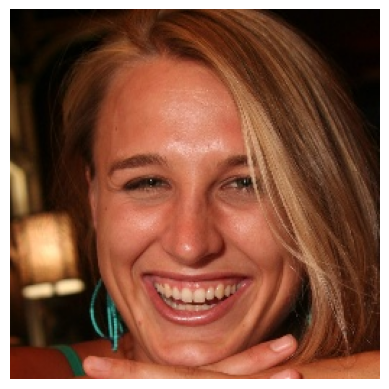

The model predicts this image is 'real' with a confidence of 100.00%.
The model predicts this image is 'fake' with a confidence of 0.00%.


In [ ]:
# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size):
    # Load image
    img = image.load_img(img_path, target_size=target_size)

    # Convert image to array
    img_array = image.img_to_array(img)

    # Rescale the image
    img_array = img_array / 255.0

    # Expand dimensions to match the input shape
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# Provide the path to your image
img_path = '/content/DATASET/real_vs_fake/real-vs-fake/test/real/00001.jpg'
target_size = (256, 256)  # Make sure this matches your model's input size

# Load and preprocess the image
img, img_array = load_and_preprocess_image(img_path, target_size)

# Make a prediction
prediction = model.predict(img_array)

# Get the percentage for both classes
real_confidence = prediction[0][0] * 100
fake_confidence = (1 - prediction[0][0]) * 100

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

# Print the results
print(f"The model predicts this image is 'real' with a confidence of {real_confidence:.2f}%.")
print(f"The model predicts this image is 'fake' with a confidence of {fake_confidence:.2f}%.")

In [ ]:
model.save_weights('/content/model/weights.weights.h5')

In [ ]:
# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size):
    # Load image
    img = image.load_img(img_path, target_size=target_size)

    # Convert image to array
    img_array = image.img_to_array(img)

    # Rescale the image
    img_array = img_array / 255.0

    # Expand dimensions to match the input shape
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# Provide the path to your image
img_path = '/content/DATASET/real_vs_fake/real-vs-fake/test/fake/00276TOPP4.jpg'
target_size = (256, 256)  # Make sure this matches your model's input size

# Load and preprocess the image
img, img_array = load_and_preprocess_image(img_path, target_size)

# Make a prediction
prediction = model.predict(img_array)

# Get the percentage for both classes
real_confidence = prediction[0][0] * 100
fake_confidence = (1 - prediction[0][0]) * 100

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

# Print the results
print(f"The model predicts this image is 'real' with a confidence of {real_confidence:.2f}%.")
print(f"The model predicts this image is 'fake' with a confidence of {fake_confidence:.2f}%.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


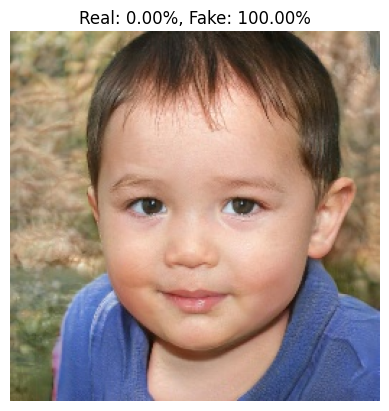

Image: KVNUMDR6PT.jpg
Real Confidence: 0.00%
Fake Confidence: 100.00%
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


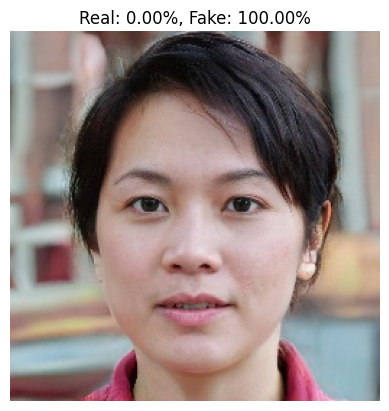

Image: SUU5MUZEAI.jpg
Real Confidence: 0.00%
Fake Confidence: 100.00%
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


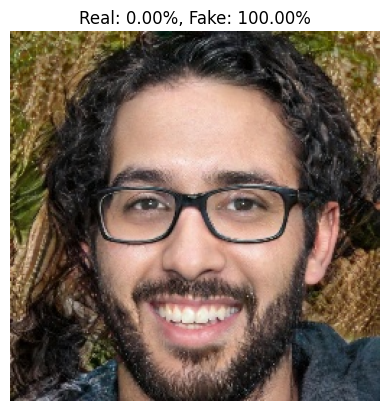

Image: N49UR9JW49.jpg
Real Confidence: 0.00%
Fake Confidence: 100.00%
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


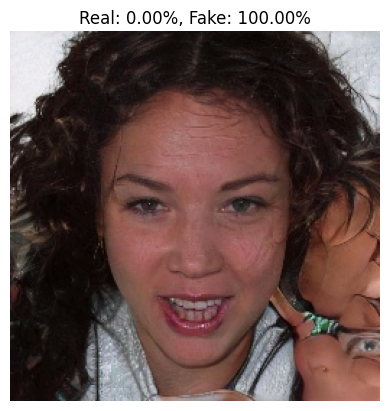

Image: Q7U21SOX4U.jpg
Real Confidence: 0.00%
Fake Confidence: 100.00%
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


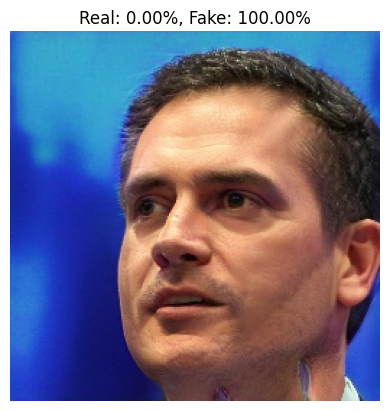

Image: NLTIK8CPR4.jpg
Real Confidence: 0.00%
Fake Confidence: 100.00%
--------------------------------------------------


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions
    return img, img_array

# Define the test dataset path
test_dir = '/content/DATASET/real_vs_fake/real-vs-fake/test/fake/'  # Change if needed
all_images = os.listdir(test_dir)

# Select 5 random images
random_images = random.sample(all_images, 5)

# Define model input size
target_size = (256, 256)  # Adjust to match your model's input

# Iterate over selected images
for img_name in random_images:
    img_path = os.path.join(test_dir, img_name)
    img, img_array = load_and_preprocess_image(img_path, target_size)

    # Make a prediction
    prediction = model.predict(img_array)
    real_confidence = prediction[0][0] * 100
    fake_confidence = (1 - prediction[0][0]) * 100

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Real: {real_confidence:.2f}%, Fake: {fake_confidence:.2f}%")
    plt.show()

    # Print the results
    print(f"Image: {img_name}")
    print(f"Real Confidence: {real_confidence:.2f}%")
    print(f"Fake Confidence: {fake_confidence:.2f}%")
    print("-" * 50)


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions
    return img, img_array

# Define the test dataset path
test_dir = '/content/DATASET/real_vs_fake/real-vs-fake/test/real/'  # Change if needed
all_images = os.listdir(test_dir)

# Select 5 random images
random_images = random.sample(all_images, 5)

# Define model input size
target_size = (256, 256)  # Adjust to match your model's input

# Iterate over selected images
for img_name in random_images:
    img_path = os.path.join(test_dir, img_name)
    img, img_array = load_and_preprocess_image(img_path, target_size)

    # Make a prediction
    prediction = model.predict(img_array)
    real_confidence = prediction[0][0] * 100
    fake_confidence = (1 - prediction[0][0]) * 100

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Real: {real_confidence:.2f}%, Fake: {fake_confidence:.2f}%")
    plt.show()

    # Print the results
    print(f"Image: {img_name}")
    print(f"Real Confidence: {real_confidence:.2f}%")
    print(f"Fake Confidence: {fake_confidence:.2f}%")
    print("-" * 50)
